1. Implement Simple Naïve Bayes classification algorithm using Python on iris.csv dataset.
2. Compute Confusion matrix to find TP, FP, TN, FN, Accuracy, Error rate, Precision, Recall on the given dataset.

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, multilabel_confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler

pd.options.display.max_columns = None

# Set Seaborn style for visualizations
sns.set(style='whitegrid', palette='muted')

In [2]:
# Load dataset
iris = pd.read_csv('Iris.csv') if 'Iris.csv' in pd.io.common.get_handle.__globals__ else pd.read_csv('iris.csv')
# Some versions include an index column; drop if present
if 'Id' in iris.columns:
    iris = iris.drop(columns=['Id'])

iris.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [3]:
iris.tail()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica
149,5.9,3.0,5.1,1.8,Iris-virginica


In [4]:
# EDA
print('Shape:', iris.shape)
print('Size:', iris.size)

Shape: (150, 5)
Size: 750


In [5]:
print('\nInfo:')
iris.info()


Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  150 non-null    float64
 1   SepalWidthCm   150 non-null    float64
 2   PetalLengthCm  150 non-null    float64
 3   PetalWidthCm   150 non-null    float64
 4   Species        150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [6]:
print('\nDescribe:')
iris.describe()


Describe:


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [7]:
print('\nClass distribution:')
iris['Species'].value_counts()


Class distribution:


Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

In [8]:
# Insert rows with null values in between the dataset
null_rows = pd.DataFrame([
    {'SepalLengthCm': 6.0, 'SepalWidthCm': 3.2, 'PetalLengthCm': np.nan, 'PetalWidthCm': 2.0, 'Species': 'Iris-virginica'},
    {'SepalLengthCm': np.nan, 'SepalWidthCm': 2.9, 'PetalLengthCm': 4.5, 'PetalWidthCm': np.nan, 'Species': 'Iris-versicolor'},
    {'SepalLengthCm': 14.0, 'SepalWidthCm': 2.9, 'PetalLengthCm': 4.5, 'PetalWidthCm': np.nan, 'Species': np.nan},
])

insert_position = 40
iris_with_null = pd.concat([iris.iloc[:insert_position], null_rows, iris.iloc[insert_position:]]).reset_index(drop=True)

print('New shape with inserted rows:', iris_with_null.shape)
iris_with_null.iloc[35:47]

New shape with inserted rows: (153, 5)


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
35,5.0,3.2,1.2,0.2,Iris-setosa
36,5.5,3.5,1.3,0.2,Iris-setosa
37,4.9,3.1,1.5,0.1,Iris-setosa
38,4.4,3.0,1.3,0.2,Iris-setosa
39,5.1,3.4,1.5,0.2,Iris-setosa
40,6.0,3.2,NaN,2.0,Iris-virginica
41,NaN,2.9,4.5,NaN,Iris-versicolor
42,14.0,2.9,4.5,NaN,NaN
43,5.0,3.5,1.3,0.3,Iris-setosa
44,4.5,2.3,1.3,0.3,Iris-setosa


In [9]:
print('\nNull counts before removal:')
print(iris_with_null.isnull().sum())


Null counts before removal:
SepalLengthCm    1
SepalWidthCm     0
PetalLengthCm    1
PetalWidthCm     2
Species          1
dtype: int64


In [10]:
# Remove null values and confirm
iris_no_null = iris_with_null.dropna().reset_index(drop=True)
print('Shape after dropna:', iris_no_null.shape)
print('\nNull counts after dropna:\n', iris_no_null.isnull().sum(), sep="")

Shape after dropna: (150, 5)

Null counts after dropna:
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64


<Figure size 800x600 with 0 Axes>

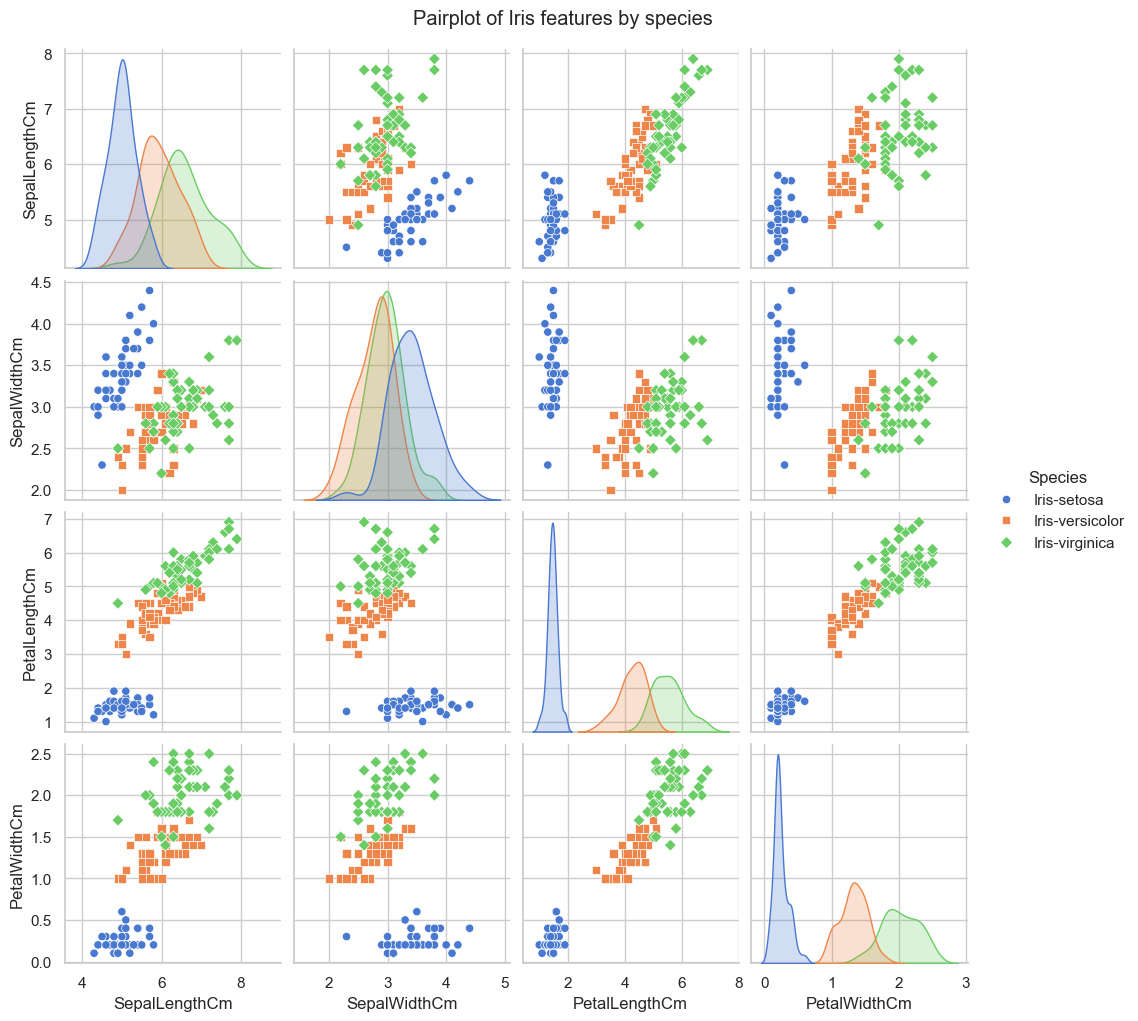

In [11]:
# Visualizations
plt.figure(figsize=(8, 6))
sns.pairplot(iris_no_null, hue='Species', markers=['o', 's', 'D'])
plt.suptitle('Pairplot of Iris features by species', y=1.02)
plt.show()

<Figure size 1000x600 with 0 Axes>

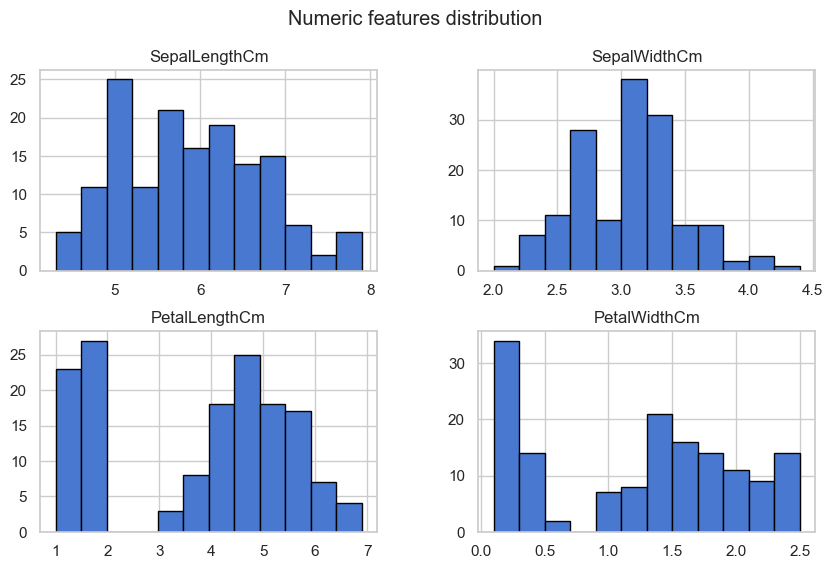

In [12]:
# Distribution
plt.figure(figsize=(10, 6))
numeric_cols = ['SepalLengthCm','SepalWidthCm','PetalLengthCm','PetalWidthCm']
iris_no_null[numeric_cols].hist(bins=12, layout=(2,2), figsize=(10,6), edgecolor='black')
plt.suptitle('Numeric features distribution')
plt.show()

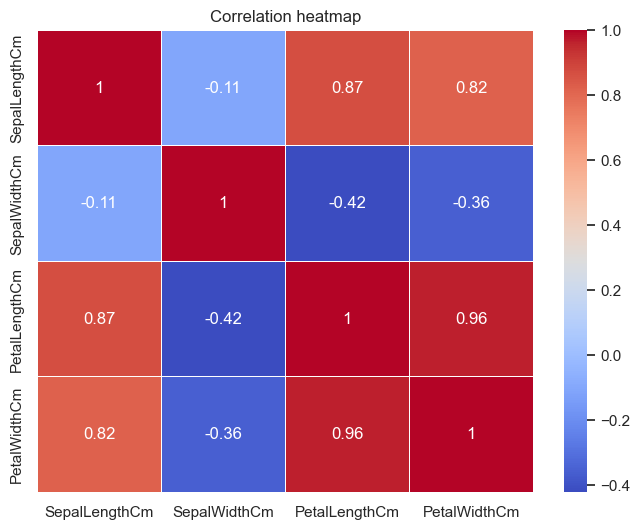

In [13]:
# Correlation between features
plt.figure(figsize=(8, 6))
sns.heatmap(iris_no_null[numeric_cols].corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation heatmap')
plt.show()

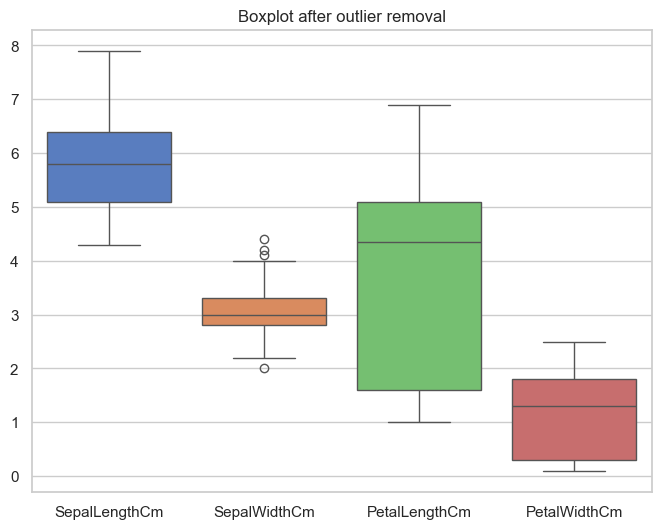

In [14]:
# Visualizations: boxplot
plt.figure(figsize=(8,6))
sns.boxplot(data=iris_no_null[numeric_cols])
plt.title('Boxplot after outlier removal')
plt.show()

Shape after outlier cleanup: (146, 5)


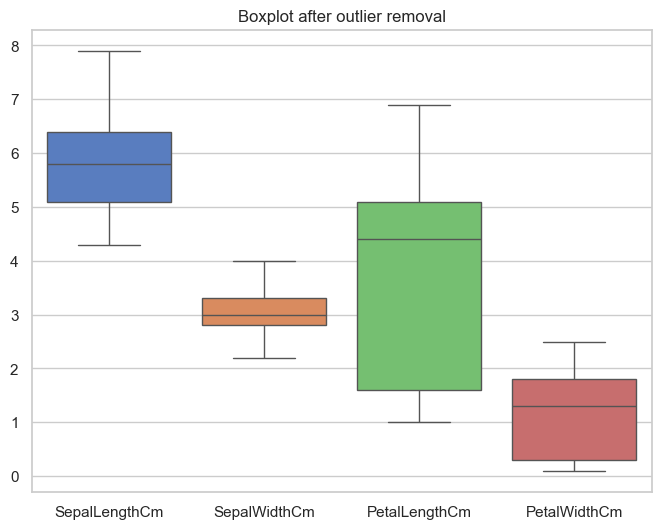

In [15]:
# Outlier detection and removal using IQR
iris_clean = iris_no_null.copy()

for col in numeric_cols:
    q1 = iris_clean[col].quantile(0.25)
    q3 = iris_clean[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    iris_clean = iris_clean[(iris_clean[col] >= lower) & (iris_clean[col] <= upper)]

print('Shape after outlier cleanup:', iris_clean.shape)

plt.figure(figsize=(8,6))
sns.boxplot(data=iris_clean[numeric_cols])
plt.title('Boxplot after outlier removal')
plt.show()

In [16]:
# Converting Categorical Column 'Species' into numeric column.
le = LabelEncoder()
iris_clean['Species_num'] = le.fit_transform(iris_clean['Species'])
print('Species mapping: ', dict(zip(le.classes_, le.transform(le.classes_))))

Species mapping:  {'Iris-setosa': np.int64(0), 'Iris-versicolor': np.int64(1), 'Iris-virginica': np.int64(2)}


In [17]:
iris_clean.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species,Species_num
0,5.1,3.5,1.4,0.2,Iris-setosa,0
1,4.9,3.0,1.4,0.2,Iris-setosa,0
2,4.7,3.2,1.3,0.2,Iris-setosa,0
3,4.6,3.1,1.5,0.2,Iris-setosa,0
4,5.0,3.6,1.4,0.2,Iris-setosa,0


In [18]:
# Separating Features and Labels for model.
X = iris_clean[numeric_cols].copy()
y = iris_clean['Species_num']

In [19]:
# Normalising the Data using Standard Scaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('First 5 scaled rows:')
pd.DataFrame(X_scaled, columns=numeric_cols).head()

First 5 scaled rows:


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,-0.910515,1.175789,-1.374878,-1.345899
1,-1.151122,-0.093924,-1.374878,-1.345899
2,-1.391729,0.413961,-1.431986,-1.345899
3,-1.512032,0.160019,-1.317771,-1.345899
4,-1.030819,1.429732,-1.374878,-1.345899


In [20]:
# Splitting the data inot Train-Test splits
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)
print('Train shape:', X_train.shape, 'Test shape:', X_test.shape)

Train shape: (116, 4) Test shape: (30, 4)


In [21]:
# Naive Bayes classification model
nb = GaussianNB()

In [22]:
# Training model on data
nb.fit(X_train, y_train)

,priors,None
,var_smoothing,1e-09


In [23]:
# Predicting the results on test data.
y_pred = nb.predict(X_test)
print('Predicted:', y_pred[:10])
print('Actual   :', y_test.values[:10])

Predicted: [1 1 2 0 2 1 2 0 2 2]
Actual   : [1 1 2 0 2 1 1 0 2 2]


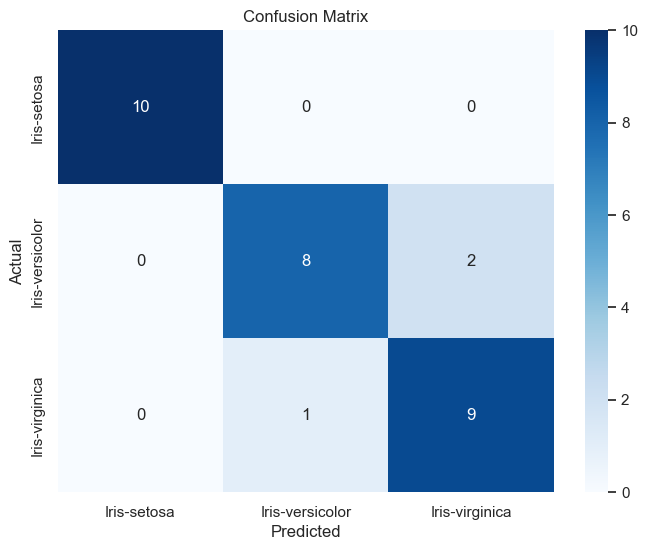

In [24]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [25]:
# Evaluation metrics from Confusion Matrix
mcm = multilabel_confusion_matrix(y_test, y_pred)
for idx, label in enumerate(le.classes_):
    tn, fp, fn, tp = mcm[idx].ravel()
    print(f'Class {label}: TP={tp}, FP={fp}, TN={tn}, FN={fn}')

accuracy = accuracy_score(y_test, y_pred)
error_rate = 1 - accuracy
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')

print(f'Accuracy: {accuracy:.4f}')
print(f'Error rate: {error_rate:.4f}')
print(f'Precision (macro): {precision:.4f}')
print(f'Recall (macro): {recall:.4f}')
print(f'F1 score (macro): {f1:.4f}')

Class Iris-setosa: TP=10, FP=0, TN=20, FN=0
Class Iris-versicolor: TP=8, FP=1, TN=19, FN=2
Class Iris-virginica: TP=9, FP=2, TN=18, FN=1
Accuracy: 0.9000
Error rate: 0.1000
Precision (macro): 0.9024
Recall (macro): 0.9000
F1 score (macro): 0.8997


In [26]:
# Detailed classification report
from sklearn.metrics import classification_report
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=le.classes_))

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.89      0.80      0.84        10
 Iris-virginica       0.82      0.90      0.86        10

       accuracy                           0.90        30
      macro avg       0.90      0.90      0.90        30
   weighted avg       0.90      0.90      0.90        30

